In [1]:
# most code comes from here https://github.com/tbonnair/Dynamical-Regimes-of-Diffusion-Models

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import torch
import sys
from tqdm import tqdm
from funs import forward, backward, score, classify, plot_speciation_3d

### Toy example

In [3]:
torch.manual_seed(123)
d = 2             # Dimension is fixed to 2
nsamples = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star = torch.tensor([4.0, 4.0])
std = 1.0

# Start with pure random noise at t=T 
x_current = torch.randn(d, nsamples) 

path_history = []

for t in tqdm(times):
    path_history.append(x_current.T.clone().numpy()) 
    x_current, _ = backward(x_current, t, dt, mu_star, std)

path_history = np.array(path_history)

100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 15204.85it/s]


Since we can solve the score function analytically, we just need to sample using he backward process
The paths' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class.

#### Speciation time $t_s$ - Analytical solution

In [4]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
print(t_s)

1.7482537641375833


#### Collapse time $t_c$ - Analytical solution

In [5]:
t_c = 1/2 * np.log(1 + std**2/(nsamples**(2/d) - 1))
print(t_c)

0.0911607783969773


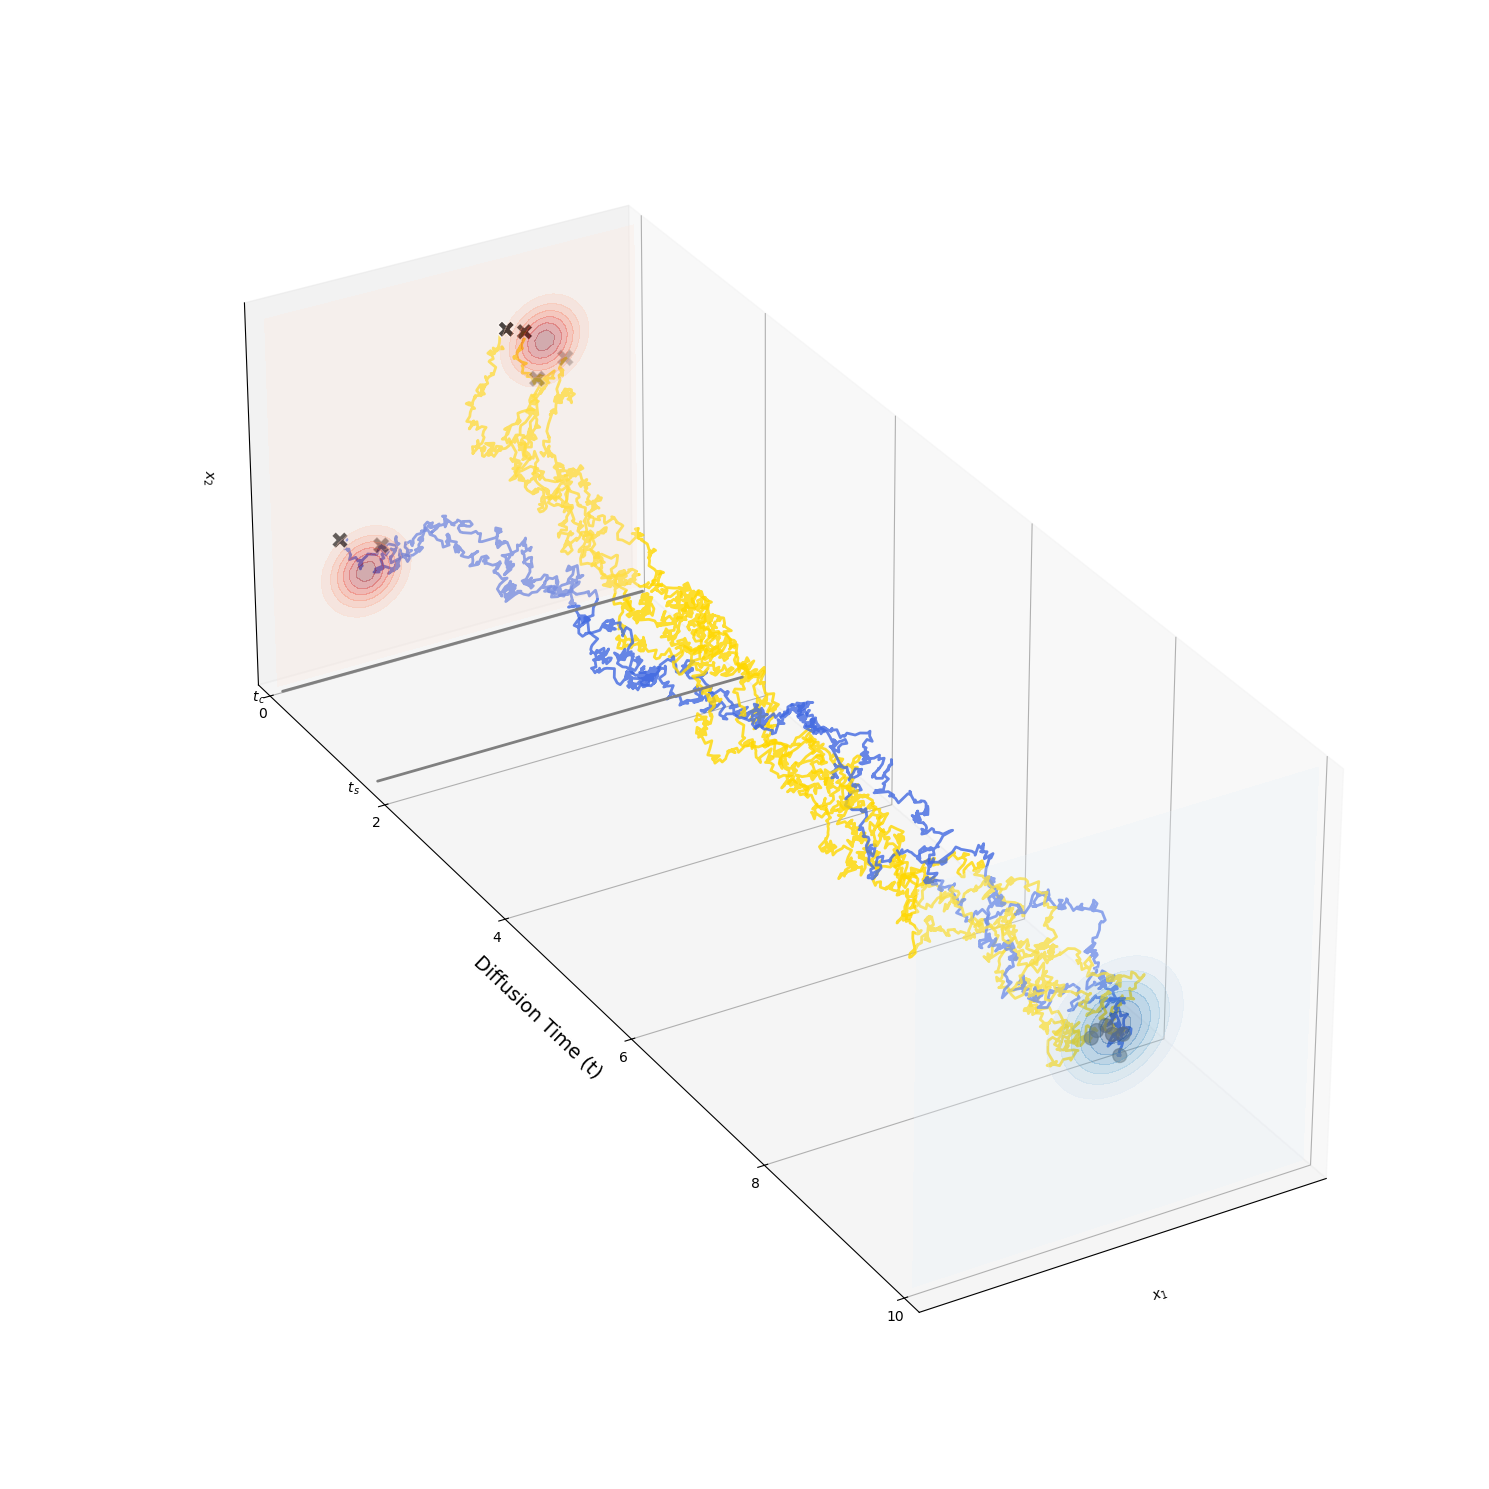

In [6]:
plot_speciation_3d(path_history, times, mu_star, std, nsamples, t_s, t_c)

### Speciation I $\rightarrow$ II- Clones experiment

The clones experiment consists on bifurcating a single particle $x_t$ into two independent "clones" $x_{t,1}$ and $x_{t,2}$ at a branching time $t$ and observing the path followed by each new clone until the end of the reverse process at time $t=0$. Both particles follow the same score function but with independent random noise contributions. $\Phi(t)$ describes the probability of the two clones landing in the same cluster.

In [ ]:
DEVICE = 'cuda'
torch.manual_seed(232)
np.random.seed(232)

ds = [256, 1024, 4096] #, 16384]
T = 10
nsteps = 1000
dt = T / nsteps
times = np.arange(0, T, dt)
nsamples = 10000
tbranches = np.arange(1, T+.5, 0.5)

In [7]:
phi_dict = {}
all_classes_dict = {}
for d in tqdm(ds, desc='t={:.2f}'.format(d)):
    mu_star = torch.ones(d, device=DEVICE)  # Center of the Gaussians are mu_star and -mu_star
    std = 1
    phi_num = np.zeros(len(tbranches))
    all_classes = np.zeros((nsamples, len(tbranches)))
    for (ib, tbranch) in enumerate(tbranches):
        x_tm1 = torch.randn(d, nsamples, device=DEVICE)     # Sample from the source distribution
        firstTime = 1                        # Boolean to know when we branch
        for t in reversed(times):
            if t > tbranch:
                x_tm1, _ = backward(x_tm1, t, dt, mu_star, std)
            else:
                if firstTime:
                    x_tm2 = x_tm1.clone()
                    x_tm3 = x_tm1.clone()
                    firstTime = 0
                x_tm2, z2 = backward(x_tm2, t, dt, mu_star, std)
                x_tm3, z3 = backward(x_tm3, t, dt, mu_star, std)
        classes_clones1 = classify(x_tm2, mu_star)
        classes_clones2 = classify(x_tm3, mu_star)
        phi_num[ib] = (classes_clones1 == classes_clones2).sum() / nsamples
        all_classes[:, ib] = np.array((classes_clones1 == classes_clones2).cpu())
    phi_dict[d] = phi_num
    all_classes_dict[d] = all_classes

d=2: 100%|███████████████████████████████████████| 3/3 [05:34<00:00, 111.43s/it]
